# 🚢 Analyse Exploratoire (EDA) - Généralisation
Ce notebook contient l'exploration initiale des données de la phase de **Généralisation** (Sujet 3).
Nous allons analyser les 4 fichiers principaux :
- `ships_large.csv`
- `radio_signatures_large.csv`
- `ais_data_large.csv`
- `anomalies_large.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Définition des chemins
DATA_DIR = '../SujetsHackathon2026/Sujet3/Généralisation'

# Chargement des données
ships_df = pd.read_csv(f'{DATA_DIR}/ships_large.csv')
radio_df = pd.read_csv(f'{DATA_DIR}/radio_signatures_large.csv')
ais_df = pd.read_csv(f'{DATA_DIR}/ais_data_large.csv')
anomalies_df = pd.read_csv(f'{DATA_DIR}/anomalies_large.csv')

print("Toutes les données ont été chargées avec succès !")


Toutes les données ont été chargées avec succès !


## 1. Analyse des Navires (`ships_large.csv`)
Cette section nous permet de comprendre le registre officiel des navires : leur pavillon (flag), leur type, et leurs caractéristiques physiques.


In [2]:
# Aperçu et informations générales
display(ships_df.info())
display(ships_df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mmsi              1000 non-null   int64  
 1   name              1000 non-null   object 
 2   imo               1000 non-null   int64  
 3   type              1000 non-null   object 
 4   flag              1000 non-null   object 
 5   length            1000 non-null   float64
 6   width             1000 non-null   float64
 7   destination       1000 non-null   object 
 8   last_ais_update   1000 non-null   object 
 9   historical_names  751 non-null    object 
 10  is_suspicious     1000 non-null   bool   
 11  year_built        1000 non-null   int64  
 12  gross_tonnage     1000 non-null   float64
dtypes: bool(1), float64(3), int64(3), object(6)
memory usage: 94.9+ KB


None

,mmsi,name,imo,type,flag,length,width,destination,last_ais_update,historical_names,is_suspicious,year_built,gross_tonnage
0,648657172,NAVIRE-7172,7851427,Container Ship,Denmark,292.1,56.5,New York,2026-03-10T10:00:00Z,"OLD_NAME_0, OLD_NAME_1",True,2006,30472.5
1,789983559,NAVIRE-3559,7086724,Container Ship,Singapore,247.3,39.6,Rotterdam,2026-05-23T20:00:00Z,"OLD_NAME_0, OLD_NAME_1",True,1996,154655.5
2,782905490,NAVIRE-5490,9403607,Passenger Ship,France,308.3,21.1,Dubaï,2026-02-24T17:00:00Z,OLD_NAME_0,False,2012,205286.4
3,705561223,NAVIRE-1223,8879598,Fishing Vessel,France,330.5,35.5,Tokyo,2026-09-19T14:00:00Z,"OLD_NAME_0, OLD_NAME_1, OLD_NAME_2",True,2008,196666.4
4,613708156,NAVIRE-8156,5259474,Fishing Vessel,Marshall Islands,314.2,28.3,Hambourg,2026-12-05T16:00:00Z,NaN,False,2017,135557.0


In [3]:
# Statistiques descriptives sur les valeurs numériques (longueur, largeur, année de construction, etc.)
display(ships_df.describe())


,mmsi,imo,length,width,year_built,gross_tonnage
count,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.036489e+08,5.533348e+06,228.838700,35.328400,2002.580000,145427.438100
std,1.760042e+08,2.626953e+06,98.200433,14.557732,13.253047,84206.666773
min,2.006982e+08,1.014779e+06,50.100000,10.100000,1980.000000,1283.100000
25%,3.544172e+08,3.298180e+06,144.500000,23.300000,1991.000000,74888.450000
50%,5.059897e+08,5.511374e+06,237.300000,34.950000,2002.000000,141913.450000
75%,6.480993e+08,7.788347e+06,309.925000,47.725000,2014.000000,215221.125000
max,7.985781e+08,9.994024e+06,399.100000,60.000000,2025.000000,299563.900000


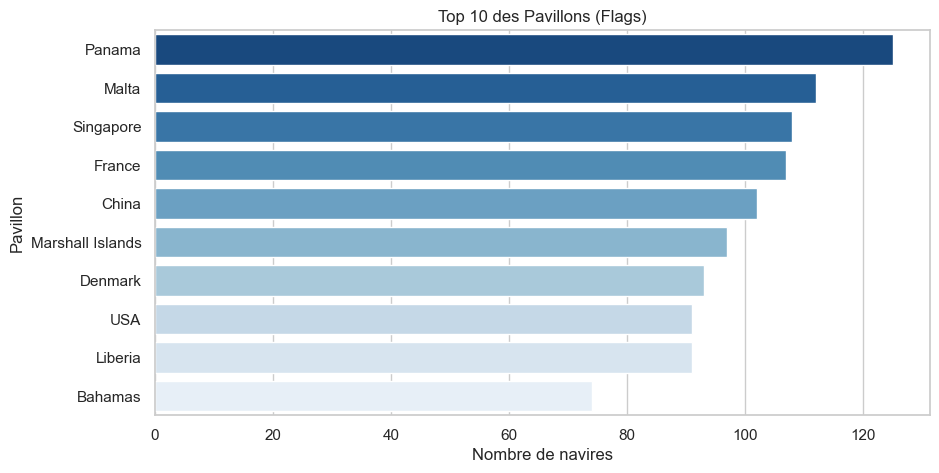

In [4]:
# Visualisation : Top 10 des pavillons (Flags)
plt.figure(figsize=(10, 5))
sns.countplot(data=ships_df, y='flag', order=ships_df['flag'].value_counts().iloc[:10].index, palette='Blues_r')
plt.title('Top 10 des Pavillons (Flags)')
plt.xlabel('Nombre de navires')
plt.ylabel('Pavillon')
plt.show()


## 2. Analyse des Signatures Radio (`radio_signatures_large.csv`)
Ce fichier contient les interceptions de signaux radio. Nous allons analyser la fréquence, la puissance, et les motifs d'impulsion (`pulse_pattern`).


In [5]:
display(radio_df.info())
display(radio_df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   signature_id           5000 non-null   object 
 1   mmsi                   5000 non-null   int64  
 2   frequency              5000 non-null   float64
 3   bandwidth              5000 non-null   float64
 4   modulation             5000 non-null   object 
 5   power                  5000 non-null   float64
 6   timestamp              5000 non-null   object 
 7   location_lat           5000 non-null   float64
 8   location_lon           5000 non-null   float64
 9   signal_strength        5000 non-null   float64
 10  noise_level            5000 non-null   float64
 11  pulse_pattern          5000 non-null   object 
 12  signal_to_noise_ratio  5000 non-null   float64
dtypes: float64(8), int64(1), object(4)
memory usage: 507.9+ KB


None

,signature_id,mmsi,frequency,bandwidth,modulation,power,timestamp,location_lat,location_lon,signal_strength,noise_level,pulse_pattern,signal_to_noise_ratio
0,SIG-00000,270851441,159.44,25.7,DSC,199.3,2026-09-07T09:00:00Z,14.3884,-25.9381,-78.4,-61.9,Long-Long-Short,4.9
1,SIG-00001,517049090,161.47,24.4,SSB,476.6,2026-06-15T15:00:00Z,-71.5206,154.0992,-105.6,-91.8,Long-Short-Long,29.2
2,SIG-00002,614022050,156.59,16.9,AM,395.0,2026-07-21T10:00:00Z,-0.4341,-149.9395,-113.3,-105.7,Short-Short-Short,1.1
3,SIG-00003,591498401,161.05,11.7,DSC,123.4,2026-04-26T16:00:00Z,57.7771,46.4227,-49.6,-118.5,Long-Short-Long,8.1
4,SIG-00004,361510820,156.68,27.2,OFDM,255.2,2026-08-21T14:00:00Z,75.1727,98.4395,-90.6,-103.5,Short-Short-Long,15.7


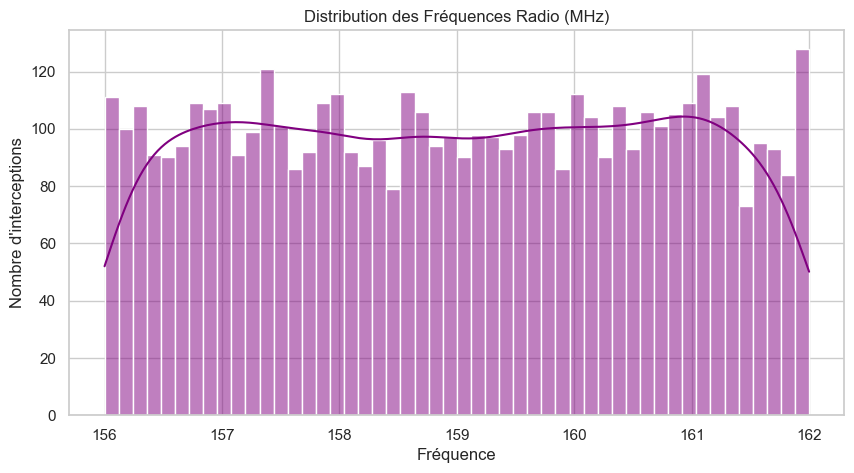

In [6]:
# Distribution des fréquences
plt.figure(figsize=(10, 5))
sns.histplot(data=radio_df, x='frequency', bins=50, kde=True, color='purple')
plt.title('Distribution des Fréquences Radio (MHz)')
plt.xlabel('Fréquence')
plt.ylabel('Nombre d\'interceptions')
plt.show()


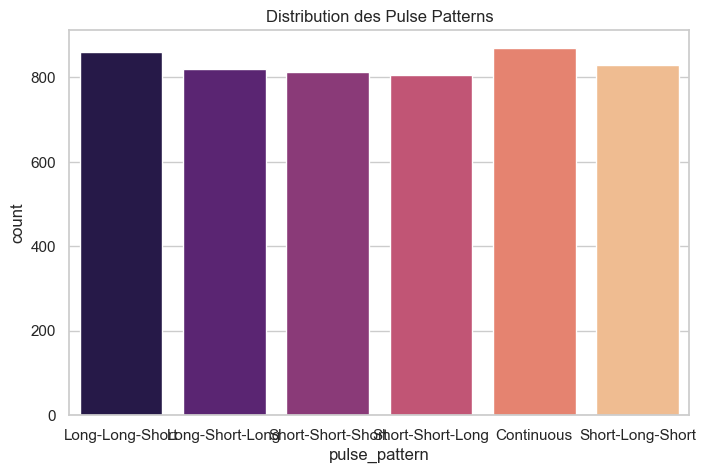

In [7]:
# Répartition des motifs d'impulsion (Pulse Patterns)
plt.figure(figsize=(8, 5))
sns.countplot(data=radio_df, x='pulse_pattern', palette='magma')
plt.title('Distribution des Pulse Patterns')
plt.show()


## 3. Analyse des données AIS (`ais_data_large.csv`)
L'AIS (Automatic Identification System) permet de suivre la position et le statut de navigation des navires.


In [8]:
display(ais_df.info())
display(ais_df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mmsi                 10000 non-null  int64  
 1   timestamp            10000 non-null  object 
 2   latitude             10000 non-null  float64
 3   longitude            10000 non-null  float64
 4   speed                10000 non-null  float64
 5   course               10000 non-null  float64
 6   status               10000 non-null  object 
 7   ais_active           10000 non-null  bool   
 8   navigational_status  10000 non-null  int64  
 9   heading              10000 non-null  float64
 10  rot                  10000 non-null  float64
dtypes: bool(1), float64(6), int64(2), object(2)
memory usage: 791.1+ KB


None

,mmsi,timestamp,latitude,longitude,speed,course,status,ais_active,navigational_status,heading,rot
0,604969493,2026-03-02T00:56:00Z,-51.6035,85.6689,2.4,160.1,Under Way,True,6,215.3,-54.5
1,563249678,2026-01-12T18:14:00Z,-0.8849,-141.1505,7.3,14.4,Moored,False,3,269.6,-26.2
2,449459316,2026-01-22T01:21:00Z,75.2526,131.0147,0.4,82.2,At Anchor,True,0,47.4,-47.6
3,418169543,2026-08-31T00:02:00Z,19.1153,-149.7675,11.2,197.5,Under Way,False,11,316.7,102.0
4,479502357,2026-07-03T05:32:00Z,-11.1119,118.1572,4.0,207.6,At Anchor,True,14,120.6,70.8


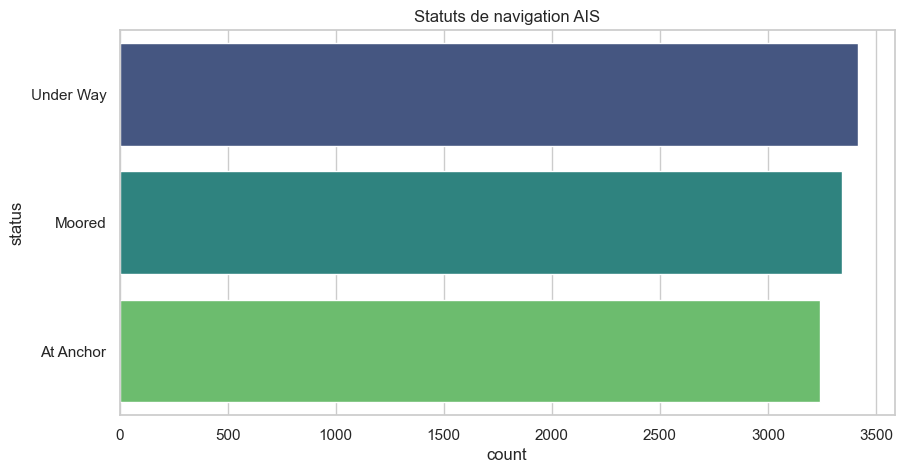

In [9]:
# Répartition des statuts de navigation
plt.figure(figsize=(10, 5))
sns.countplot(data=ais_df, y='status', order=ais_df['status'].value_counts().index, palette='viridis')
plt.title('Statuts de navigation AIS')
plt.show()


## 4. Analyse des Anomalies détectées (`anomalies_large.csv`)
Ceci est une liste d'anomalies déjà identifiées par le système de renseignement. Analysons les types d'anomalies les plus fréquents.


In [10]:
display(anomalies_df.info())
display(anomalies_df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   anomaly_id   100 non-null    object 
 1   mmsi         100 non-null    int64  
 2   type         100 non-null    object 
 3   description  100 non-null    object 
 4   timestamp    100 non-null    object 
 5   confidence   100 non-null    float64
 6   source       100 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 5.6+ KB


None

,anomaly_id,mmsi,type,description,timestamp,confidence,source
0,ANOM-000,591498401,AIS Disabled,"AIS désactivé depuis 24h, mais signature radio...",2026-04-11T00:00:00Z,0.86,Radio Signature
1,ANOM-001,666126066,Speed Anomaly,Vitesse anormale : 43.4 nœuds (limite : 30 nœu...,2026-03-02T00:00:00Z,0.76,AIS Inconsistency
2,ANOM-002,616945014,Speed Anomaly,Vitesse anormale : 38.7 nœuds (limite : 30 nœu...,2026-05-05T00:00:00Z,0.72,Manual Review
3,ANOM-003,780872220,AIS Disabled,"AIS désactivé depuis 24h, mais signature radio...",2026-05-11T00:00:00Z,0.95,AIS Inconsistency
4,ANOM-004,393509366,Speed Anomaly,Vitesse anormale : 32.1 nœuds (limite : 30 nœu...,2026-01-30T00:00:00Z,0.78,AIS Inconsistency


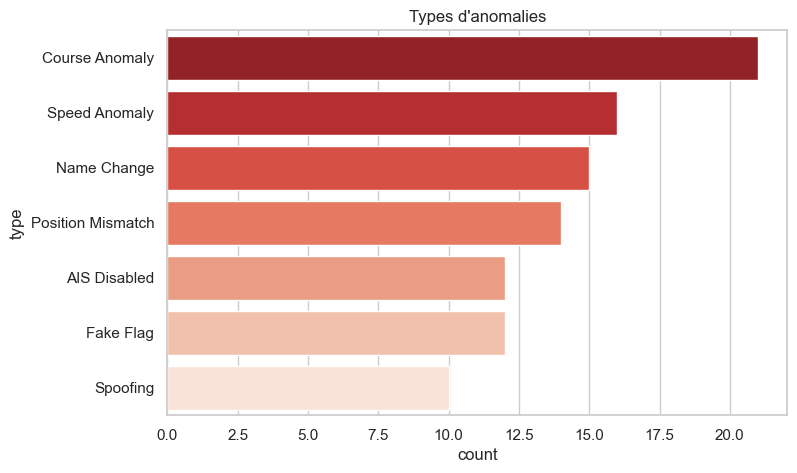

In [11]:
# Distribution des types d'anomalies
plt.figure(figsize=(8, 5))
sns.countplot(data=anomalies_df, y='type', order=anomalies_df['type'].value_counts().index, palette='Reds_r')
plt.title('Types d\'anomalies')
plt.show()
